# Phase 7 - A Gymnasium environment for reinforcement learning

This phase turns the simulator into something an RL algorithm can train on: a standard
[Gymnasium](https://gymnasium.farama.org/) environment, `JetEnv`. The design choices made here,
what the agent *sees*, what it *controls*, how it is *rewarded*, when an episode *ends*  matter
as much as the learning algorithm itself.

Code: `src/jetfighter_rl/envs/` : `jet_env.py`, `rewards.py`, `baselines.py`, `tasks/`.

In [1]:
%matplotlib inline
import math
import time

import matplotlib.pyplot as plt
import numpy as np
from gymnasium.utils.env_checker import check_env
from jetsim.aircraft import dynamics_3dof as d3
from jetsim.aircraft.envelope import Violation
from jetsim.aircraft.instruments import read_instruments
from jetsim.aircraft.params import load_aircraft
from jetsim.core.integrators import simulate
from jetsim.viz.style import INK, INK_2, SERIES, apply_style

from jetfighter_rl.envs.baselines import AutopilotPolicy, RandomPolicy, evaluate
from jetfighter_rl.envs.jet_env import EnvConfig, JetEnv, action_to_command, gravity_compensation

apply_style()
plt.rcParams["figure.dpi"] = 110
DEG = math.pi / 180


def fmt(ev):
    return (
        f"return {ev.mean_return:7.1f} ± {ev.std_return:5.1f} | success {ev.success_rate:4.0%}"
        f" | crash {ev.crash_rate:4.0%}"
    )

## 1. The reinforcement-learning problem

RL frames control as a **Markov decision process**: at each step $t$ the agent observes $o_t$,
chooses an action $a_t \sim \pi_\theta(\cdot \mid o_t)$, the environment moves on and returns a
reward $r_t$. The agent learns the policy parameters $\theta$ that maximize the expected
**discounted return**

$$J(\theta) = \mathbb E_{\pi_\theta}\Big[\sum_{t=0}^{T} \gamma^t\, r_t\Big], \qquad \gamma = 0.99$$

With a decision every 0.1 s, $\gamma = 0.99$ means the agent effectively "looks"
$1/(1-\gamma) = 100$ steps = **10 s** ahead. Everything below defines $o_t$, $a_t$, $r_t$ and $T$.

## 2. The environment API

`JetEnv` follows the Gymnasium interface exactly, and passes Gymnasium's own `check_env` on all
combinations of task × model (3-DOF / 6-DOF) × action mode:

In [2]:
env = JetEnv(EnvConfig(task="level", model="3dof"))
obs, info = env.reset(seed=0)
print("observation space:", env.observation_space)
print("action space:     ", env.action_space)
obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
print(f"one step: reward {reward:.3f}, terminated={terminated}, truncated={truncated}")
print(
    "reward terms of that step:", {k: round(float(v), 4) for k, v in info["reward_terms"].items()}
)

for model in ("3dof", "6dof"):
    for mode in ("hierarchical", "low_level"):
        check_env(
            JetEnv(EnvConfig(task="heading_altitude", model=model, action_mode=mode)),
            skip_render_check=True,
        )
print("\ncheck_env: OK on all 4 model × action-mode combinations")

observation space: Box(-10.0, 10.0, (22,), float32)
action space:      Box(-1.0, 1.0, (3,), float32)
one step: reward -0.657, terminated=False, truncated=False
reward terms of that step: {'bank': -0.1467, 'gamma': -0.5, 'speed': -0.0007, 'smoothness': -0.0097, 'success': 0.0}

check_env: OK on all 4 model × action-mode combinations


Three clocks run inside each `step`: physics at **100 Hz**, the fly-by-wire inner loop and the
envelope monitor at **50 Hz**, the agent's decision at **10 Hz**. One agent step therefore
covers 5 inner-loop steps and 10 RK4 physics steps.

## 3. Actions: hierarchical first

The project's key architectural decision: the agent does **not** start by moving control
surfaces. In `hierarchical` mode (default) it outputs three numbers in $[-1, 1]$ that become a
`HighLevelCommand` for the fly-by-wire of [notebook 6](https://github.com/elouansalaun/jetfighter-sim/blob/main/notebooks/06_classical_control.ipynb):

| action | meaning | mapping |
|---|---|---|
| $a_0$ | load factor $n_z$ | $a_0 = 0 \to n_{hold}$, $a_0 = +1 \to +9$ g, $a_0 = -1 \to -3$ g (piecewise linear) |
| $a_1$ | roll rate | $\pm 180°/s$ |
| $a_2$ | throttle | $(a_2 + 1)/2$ |

where $n_{hold} = \cos\gamma / \cos\mu$ is the load factor that **holds the current flight path**.
The first version used $a_0 = 0 \to 1$ g: in a 60° banked turn the agent then had to output
precisely $1/\cos 60° = 2$ g to not descend, and PPO never learned the heading/altitude task.
Making "zero = keep doing what you do" fixed it.

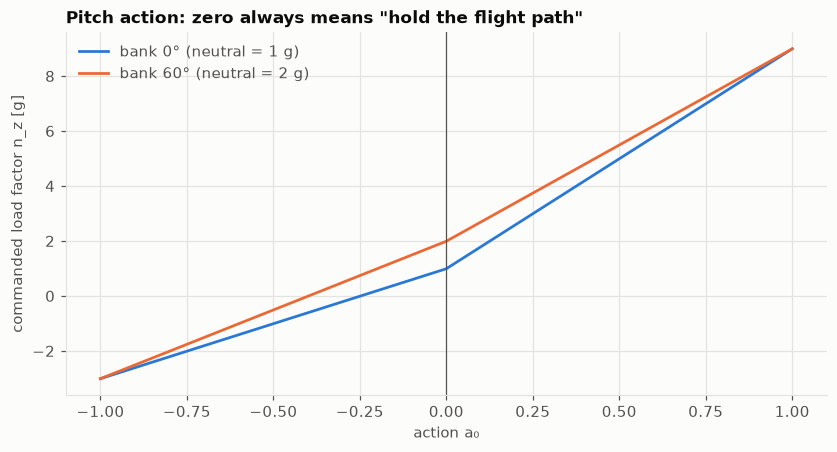

In [3]:
a0 = np.linspace(-1, 1, 201)
fig, ax = plt.subplots(figsize=(7.5, 4), layout="constrained")
for bank, color in zip((0, 60), SERIES, strict=False):
    bias = gravity_compensation(0.0, bank * DEG)
    nz = [action_to_command(np.array([a, 0.0, 0.0]), 180 * DEG, nz_bias=bias).nz for a in a0]
    ax.plot(a0, nz, color=color, label=f"bank {bank}° (neutral = {bias:.0f} g)")
ax.axvline(0, color=INK_2, linewidth=0.8)
ax.set_xlabel("action a₀"), ax.set_ylabel("commanded load factor n_z [g]")
ax.set_title('Pitch action: zero always means "hold the flight path"')
ax.legend(loc="upper left")
plt.show()

The `low_level` mode (step 8.6, the final goal) instead maps the 4 actions directly to throttle,
elevator, ailerons and rudder ; no limiter, no stability augmentation.

## 4. Observations

The observation is a flat vector, normalized to roughly $[-1, 1]$ (clipped at ±10):

* **own ship (19)**: speed, altitude, Mach, vertical speed, attitude (6), α, β, p, q, r, $n_z$,
  specific excess power, engine power;
* **previous action (3)** : lets the policy be smooth;
* **task features** : errors relative to the goal (e.g. altitude error, sin/cos of heading error).

Angles are never given raw (a heading of +179° and −179° are neighbors), but as sines/cosines or,
for the attitude, as the **direction of gravity** seen from the aircraft. That last choice came
from a failure: with Euler angles, an aerobatics agent climbed to the vertical and *stopped*,
because its observation flipped by 180° there ([notebook 1](https://github.com/elouansalaun/jetfighter-sim/blob/main/notebooks/01_physics_foundations.ipynb)). Here is the difference over a loop:

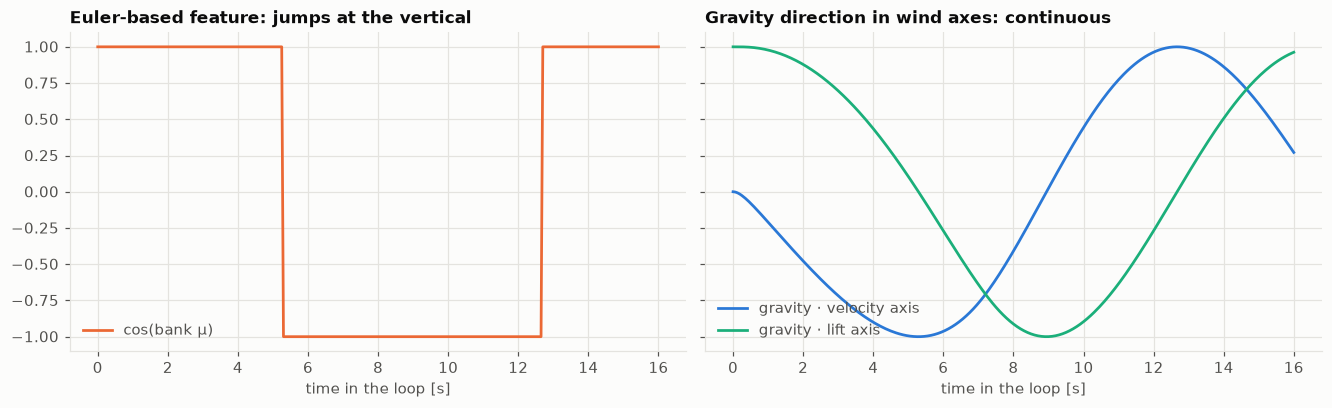

In [4]:
ac = d3.PointMassAircraft(load_aircraft("f16"))
x0, _ = ac.trimmed_state(3000, 280)
res = simulate(
    ac.derivatives, x0, 16.0, u_const=np.array([1.0, 25 * DEG, 0.0]), post_step=ac.post_step
)
euler_feat, gravity_feat = [], []
for x in res.x[::5]:
    m = read_instruments(ac, x)
    euler_feat.append((math.sin(m.bank), math.cos(m.bank)))
    cg = math.cos(m.gamma)
    gravity_feat.append((-math.sin(m.gamma), math.cos(m.bank) * cg))  # gravity in wind axes
t_feat = res.t[::5]
euler_feat, gravity_feat = np.array(euler_feat), np.array(gravity_feat)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), layout="constrained", sharey=True)
axes[0].plot(t_feat, euler_feat[:, 1], color=SERIES[1], label="cos(bank μ)")
axes[0].set_title("Euler-based feature: jumps at the vertical")
axes[1].plot(t_feat, gravity_feat[:, 0], color=SERIES[0], label="gravity · velocity axis")
axes[1].plot(t_feat, gravity_feat[:, 1], color=SERIES[2], label="gravity · lift axis")
axes[1].set_title("Gravity direction in wind axes: continuous")
for ax in axes:
    ax.set_xlabel("time in the loop [s]")
    ax.legend(loc="lower left")
plt.show()

Observations are computed from the **measured** instruments (optionally noisy, [notebook 4](https://github.com/elouansalaun/jetfighter-sim/blob/main/notebooks/04_instruments_envelope.ipynb)),
while rewards and terminations use the **true** state ; the agent cannot game its sensors.

## 5. Rewards

Each task returns a dictionary of **named terms**, summed into the reward and logged separately
(in `info` and TensorBoard), so one can see *which* term drives learning. Conventions: costs are
negative and bounded in about $[-1, 0]$ per step, bonuses are small and positive. For the
stabilization task (8.1):

$$r_t = -0.5\,\frac{|\mu|}{\pi} - 0.5\,\min\!\Big(\frac{|\gamma|}{20°}, 1\Big)
        - 0.1\,\min\!\Big(\frac{|V - V_0|}{50}, 1\Big)
        - 0.1\,\frac{\overline{(a_t - a_{t-1})^2}}{4} + 0.1\cdot\mathbb 1[\text{wings level}]$$

The smoothness term penalizes jerky commands; the speed term exists because early agents
recovered quickly and then let the speed decay forever, visible only on the trajectories.

### Termination and the crash penalty

An episode is `terminated` when the envelope monitor detects a crash/overload/stall (or the task
is accomplished), `truncated` at the time limit. The crash penalty turned out to be subtle. A
fixed −50 was not enough: far from the goal, each step costs up to $c_{max}$, so *crashing early
was cheaper than flying on*, and the agent learned to end episodes. The fix charges the worst
cost of all remaining steps within the agent's horizon:

$$r_{crash} = -50 - c_{max}\cdot\min\!\left(\frac{T - t}{\Delta t},\ \frac{1}{1-\gamma}\right)$$

In [5]:
c_max = env.task.max_step_cost
for t_crash in (5.0, 15.0, 25.0):
    remaining = (30.0 - t_crash) / 0.1
    penalty = -50 - c_max * min(remaining, 100)
    fly_on = -c_max * sum(0.99**k for k in range(int(remaining)))
    print(
        f"crash at t = {t_crash:4.1f} s: penalty {penalty:7.1f}   vs  flying on at the worst "
        f"cost: {fly_on:6.1f} (discounted)"
    )

crash at t =  5.0 s: penalty  -170.0   vs  flying on at the worst cost: -110.3 (discounted)
crash at t = 15.0 s: penalty  -170.0   vs  flying on at the worst cost:  -93.4 (discounted)
crash at t = 25.0 s: penalty  -110.0   vs  flying on at the worst cost:  -47.4 (discounted)


Crashing is now always the worst option, whatever the situation.

## 6. Baselines: autopilot versus random

Every task provides a **reference policy** (the phase-6 autopilot plugged into the action space)
and is evaluated on fixed seeds. On the stabilization task, starting from random unusual
attitudes (bank up to ±80°, climb/dive up to ±25°, roll rate up to ±60°/s):

autopilot  episode: terms = bank -0.3, gamma -7.4, speed -0.5, smoothness -0.0, success +27.5
random     episode: terms = bank -73.3, gamma -131.5, speed -19.3, smoothness -5.0, success +0.0


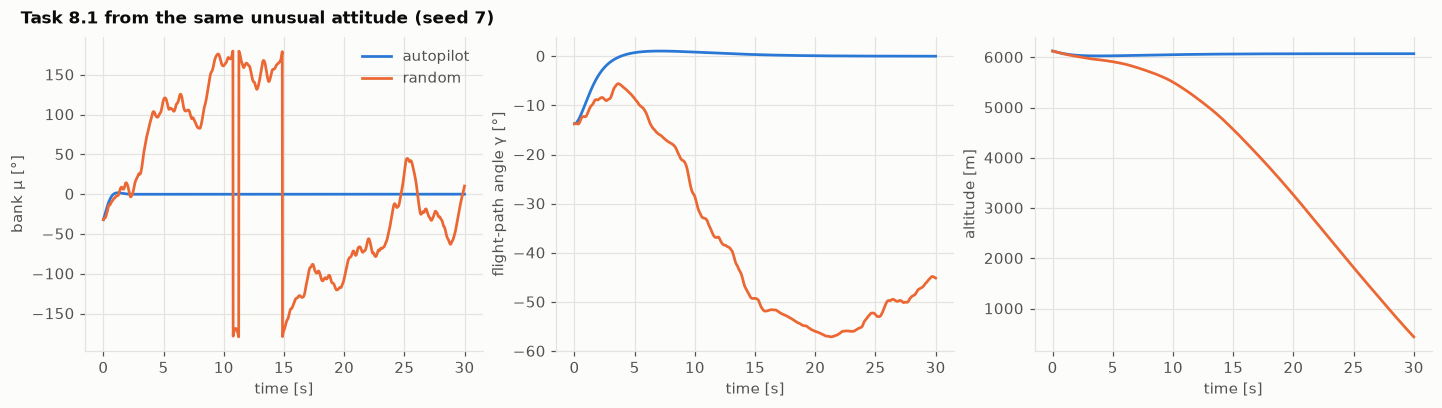

In [6]:
def violation_name(message):
    """Envelope messages are in French; map them back to the enum name."""
    return next((v.name for v in Violation if message.startswith(v.value)), message)


env = JetEnv(EnvConfig(task="level", model="3dof", record=True))
policies = {"autopilot": AutopilotPolicy(env), "random": RandomPolicy(env, seed=0)}
flights = {}
for name, policy in policies.items():
    obs, info = env.reset(seed=7)
    policy.reset()
    done = False
    while not done:
        obs, reward, terminated, truncated, info = env.step(policy(obs))
        done = terminated or truncated
    flights[name] = (env.recording(), info)
    print(
        f"{name:<10} episode: terms = "
        + ", ".join(f"{k} {v:+.1f}" for k, v in info["episode_terms"].items())
        + (f"  -> ended by {violation_name(info['violation'])}" if info["violation"] else "")
    )

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), layout="constrained")
for (name, (rec, _)), color in zip(flights.items(), SERIES, strict=False):
    ins = rec.instruments
    axes[0].plot(rec.t, np.degrees(ins["bank"]), color=color, label=name)
    axes[1].plot(rec.t, np.degrees(ins["gamma"]), color=color, label=name)
    axes[2].plot(rec.t, ins["altitude"], color=color, label=name)
axes[0].set_ylabel("bank μ [°]"), axes[1].set_ylabel("flight-path angle γ [°]")
axes[2].set_ylabel("altitude [m]")
for ax in axes:
    ax.set_xlabel("time [s]")
axes[0].legend(loc="upper right")
fig.suptitle(
    "Task 8.1 from the same unusual attitude (seed 7)",
    color=INK,
    fontweight="bold",
    x=0.01,
    ha="left",
)
plt.show()

In [7]:
for task in ("level", "heading_altitude"):
    env = JetEnv(EnvConfig(task=task, model="3dof"))
    print(f"{task:<17} autopilot: {fmt(evaluate(env, AutopilotPolicy(env), episodes=10))}")
    print(f"{'':<17} random:    {fmt(evaluate(env, RandomPolicy(env), episodes=10))}")

level             autopilot: return    17.2 ±   9.1 | success 100% | crash   0%
                  random:    return  -212.1 ±  52.4 | success   0% | crash  30%
heading_altitude  autopilot: return    70.7 ±  46.2 | success 100% | crash   0%
                  random:    return  -523.3 ± 107.0 | success   0% | crash 100%


The autopilot succeeds everywhere; random actions score between −200 and −500 (on the
heading/altitude task every random episode ends in a crash).
An RL agent starts near the random policy, the question for notebook 8 is how far above the
autopilot it can get.

## 7. Speed matters

RL needs millions of steps, so simulator throughput is a real constraint:

In [8]:
for model in ("3dof", "6dof"):
    env = JetEnv(EnvConfig(task="heading_altitude", model=model))
    env.reset(seed=0)
    n, t0 = 0, time.perf_counter()
    while time.perf_counter() - t0 < 2.0:
        _, _, term, trunc, _ = env.step(np.zeros(3, np.float32))
        n += 1
        if term or trunc:
            env.reset()
    rate = n / (time.perf_counter() - t0)
    print(
        f"{model}: {rate:6.0f} agent steps/s on one core = {rate * 0.1:5.0f}× real time "
        f"({rate * 10:,.0f} physics steps/s)"
    )

3dof:   2042 agent steps/s on one core =   204× real time (20,421 physics steps/s)
6dof:    519 agent steps/s on one core =    52× real time (5,192 physics steps/s)


Training runs 8 environments in parallel processes (`SubprocVecEnv`). On a laptop, 1 million
steps then take roughly 5 minutes in 3-DOF and 20 minutes in 6-DOF.

## 8. The task catalogue

A task is a small class that defines *what* to learn : initial conditions, goals, observation
features, reward terms, success criterion, reference policy, while `JetEnv` defines *how the
aircraft flies*. Adding a task never touches the environment code.

| Task | Step | Episode | Goal | Success criterion |
|---|---|---|---|---|
| `level` | 8.1 | 30 s | recover wings-level from an unusual attitude | level (\|μ\| < 5°, \|γ\| < 2°) within 10 s |
| `heading_altitude` | 8.2 | 90 s | reach a random heading, altitude (±1500 m), speed | within 30 m / 3° / 5 m/s, limited overshoot |
| `sustained_turn` | 8.3 | 60 s | turn at the best *sustainable* rate | ≥ 90 % of optimal rate, altitude ±200 m, no energy loss |
| `waypoints` | 8.4 | 300 s | fly through 4 random 3D waypoints | all 4 captured |
| `aerobatics` | 8.5 | 45 s | loop, aileron roll, Immelmann, Split-S | figure completed, wings level at the right heading |

## Takeaways

* A standard **Gymnasium** interface means any off-the-shelf algorithm (PPO, SAC…) can train
  on the simulator.
* **Hierarchical actions** with a "hold the flight path" neutral make the problem learnable;
  **low-level actions** remain available for the final challenge.
* Observations avoid discontinuities (**sin/cos, gravity direction**); rewards are **modular and
  logged per term**; the **crash penalty** is designed so that crashing is never a shortcut.
* Each task ships a **reference policy**, so every training run is compared to the autopilot on
  the same seeds.

**Next:** notebook 8 trains the agents.